In [6]:

import numpy as np

class DBSCANFromScratch:
    def __init__(self,eps=0.5,min_samples=5):
        
        self.eps = eps
        self.min_samples = min_samples
        self.labels_ = None
        
        self.UNVISITED = -99
        self.NOISE  = -1
        
    def _euclidean_distance(self,point_a,point_b):
        
        return np.sqrt(np.sum((point_a-point_b) ** 2))
    
    def _region_query(self,X,point_index):
        
        neighbors = []
        
        for i in range(len(X)):
            distance = self._euclidean_distance(X[point_index],X[i])
            
            
            if distance <= self.eps:
                neighbors.append(i)
                
        return neighbors
    
    
    def _expand_cluster(self,X,point_index,neighbors,cluster_id):
        
        self.labels_[point_index] = cluster_id
        
        i = 0
        
        while i< len(neighbors):
            neighbor_index = neighbors[i]
            
            
            if self.labels_[neighbor_index] == self.NOISE:
                self.labels_[neighbor_index] = cluster_id
                
            if self.labels_[neighbor_index] == self.UNVISITED:
                self.labels_[neighbor_index] = cluster_id
                
                neighbor_neighbors = self._region_query(X,neighbor_index)
                
                if len(neighbor_neighbors) >= self.min_samples:
                    for n in neighbor_neighbors:
                        if n not in neighbors:
                            neighbors.append(n)
                            
            i+= 1
            
    def fit(self,X):
        
        X = np.array(X)
        
        n_samples = len(X)
        
        self.labels_ = np.full(n_samples,self.UNVISITED)
        
        cluster_id = 0
        
        for point_index in range(n_samples):
            
            if self.labels_[point_index] != self.UNVISITED:
                continue
            
            neighbors = self._region_query(X,point_index)
            
            
            if len(neighbors)< self.min_samples:
                self.labels_[point_index] = self.NOISE
                
            else:
                self._expand_cluster(X,point_index,neighbors,cluster_id)
                cluster_id +=1
                
        return self 
    def fit_predict(self,X):
        self.fit(X)
        return self.labels_
    

In [8]:

import numpy as np
import matplotlib.pyplot as plt


X = np.array([
    [1.0, 2.0],
    [1.1, 2.1],
    [0.9, 1.9],
    [1.2, 2.0],

    [5.0, 8.0],
    [5.1, 8.1],
    [4.9, 7.9],
    [5.2, 8.0],

    [10.0, 10.0]  # noise data 
])


dbscan = DBSCANFromScratch(eps=0.35, min_samples=3)
labels = dbscan.fit_predict(X)

print(labels)

[ 0  0  0  0  1  1  1  1 -1]


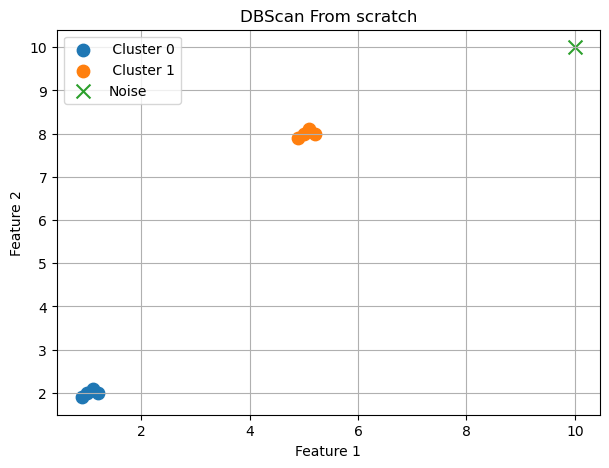

In [9]:
plt.figure(figsize=(7,5))

unique_labels = set(labels)


for label in unique_labels:
    cluster_points = X[labels == label]
    
    if label == -1:
        plt.scatter(
            cluster_points[:,0],
            cluster_points[:,1],
            marker='x',
            s=100,
            label='Noise'
        )
    else:
        plt.scatter(
            cluster_points[:,0],
            cluster_points[:,1],
            s = 80,
            label=f' Cluster {label}'
        )
        
plt.title('DBScan From scratch')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN



X = np.array([
    [1.0, 2.0],
    [1.1, 2.1],
    [0.9, 1.9],
    [1.2, 2.0],

    [5.0, 8.0],
    [5.1, 8.1],
    [4.9, 7.9],
    [5.2, 8.0],

    [10.0, 10.0]
])


model = DBSCAN(eps=0.35, min_samples=3)
labels = model.fit_predict(X)

print(labels)

[ 0  0  0  0  1  1  1  1 -1]
